In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,StandardScaler
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,BaggingClassifier
from sklearn.tree import DecisionTreeClassifier




In [17]:
df=pd.read_csv('WineQT.csv')

In [18]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [19]:
df.shape

(1143, 13)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [21]:
df.drop(columns=['Id'],inplace=True)

In [22]:
df.duplicated().sum()

np.int64(125)

In [23]:
# removing duplicates
df=df.drop_duplicates().reset_index(drop=True)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [26]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [27]:
numerical_cols=df.select_dtypes(include=(np.number)).columns.tolist()
cat_cols=df.select_dtypes(include=('object')).columns.tolist()

In [28]:
numerical_cols

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [29]:
cat_cols

[]

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


EDA

In [31]:
len(numerical_cols)

12

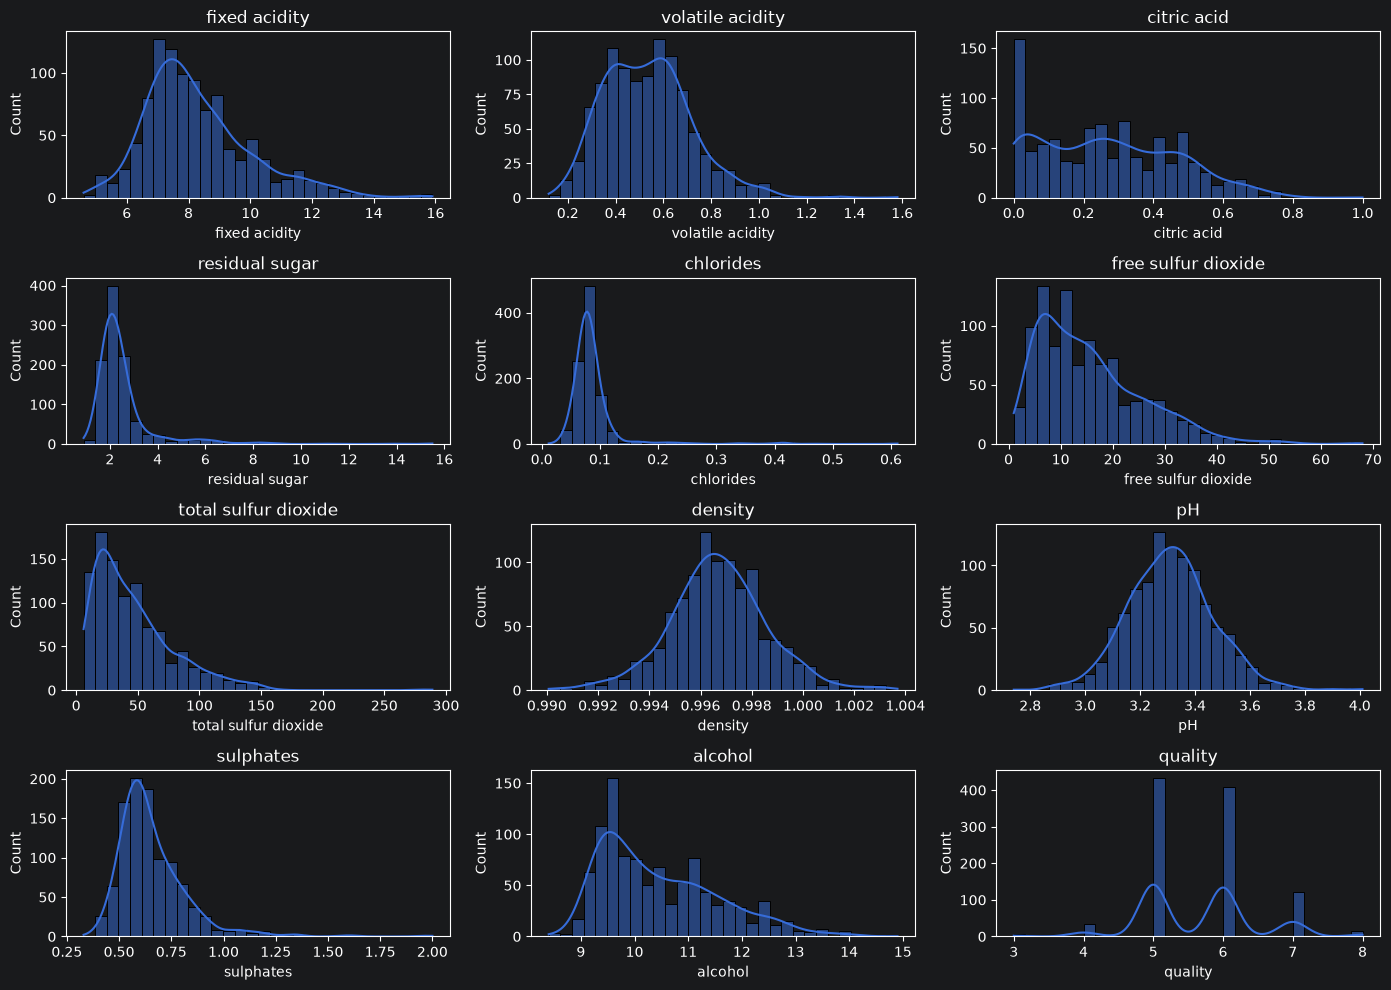

In [32]:
fig,axes=plt.subplots(4,3,figsize=(14,10))
axes=axes.flatten()

for idx,col in enumerate(numerical_cols):
    sns.histplot(df[col],bins=30,kde=True,ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()


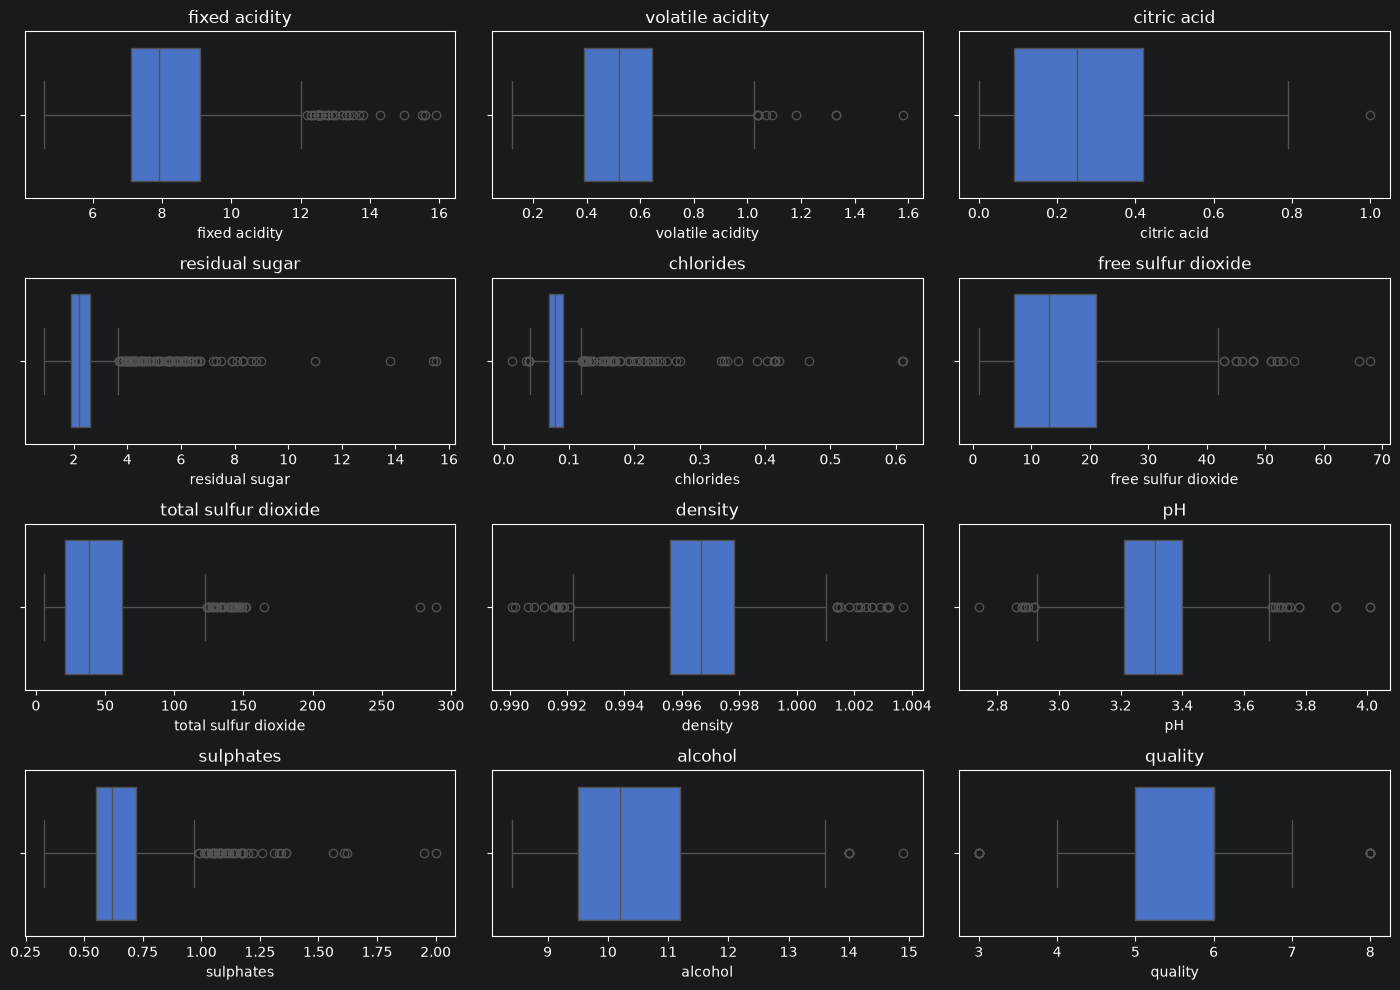

In [33]:
fig,axes=plt.subplots(4,3,figsize=(14,10))
axes=axes.flatten()

for idx,col in enumerate(numerical_cols):
    sns.boxplot(x=df[col],ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

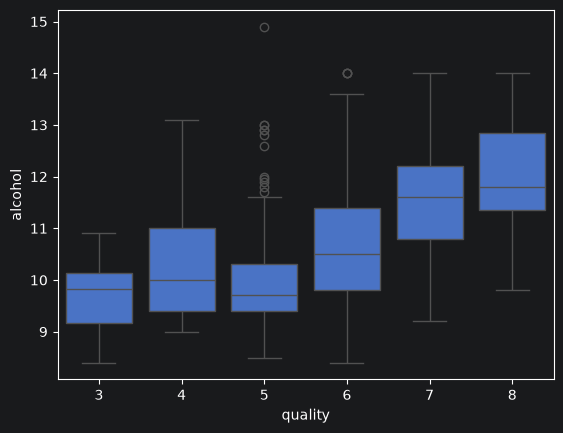

In [34]:
sns.boxplot(x='quality',y='alcohol',data=df)
plt.show()

Alcohol content shows a generally positive relationship with wine quality. While the median alcohol levels for quality 3–5 are relatively similar, median alcohol increases noticeably for quality 6–8. Quality 5 also contains several high-alcohol potential outliers.

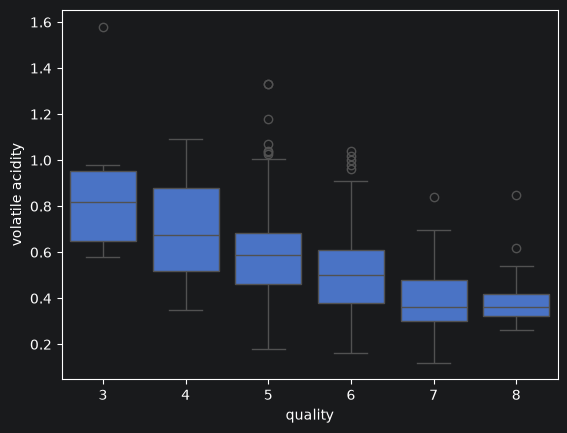

In [35]:
sns.boxplot(x='quality',y='volatile acidity',data=df)
plt.show()

Volatile acidity shows a clear negative relationship with wine quality. The median volatile acidity decreases progressively as quality increases. Several quality groups also contain potential high-value outliers, particularly among lower-quality wines.

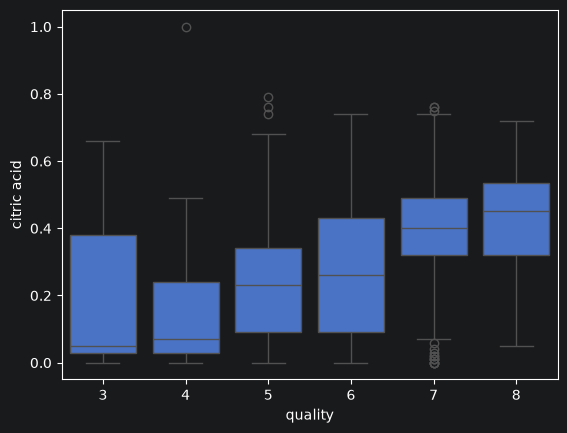

In [36]:
sns.boxplot(x='quality',y='citric acid',data=df)
plt.show()

Citric acid shows a generally positive association with wine quality, with median values tending to increase toward higher quality scores. Several groups exhibit high-value potential outliers and asymmetric distributions.


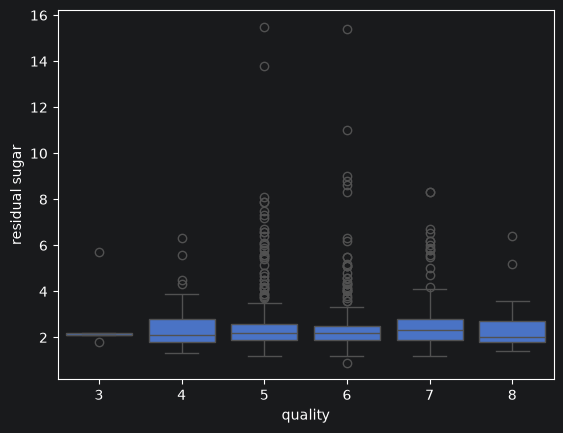

In [37]:
sns.boxplot(x='quality',y='residual sugar',data=df)
plt.show()

Residual sugar shows no strong visible relationship with wine quality, as the median remains relatively stable across quality levels. However, the feature contains numerous high-value potential outliers.

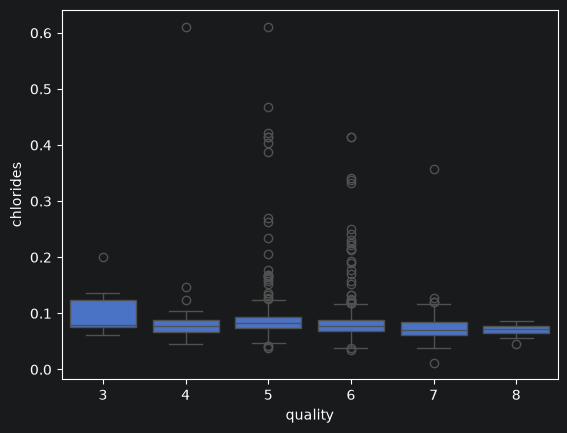

In [38]:
sns.boxplot(x='quality',y='chlorides',data=df)
plt.show()

Chlorides show no clear trend across wine quality, while their distributions are highly concentrated at low values indicating highly right skewed with numerous high-value potential outliers.

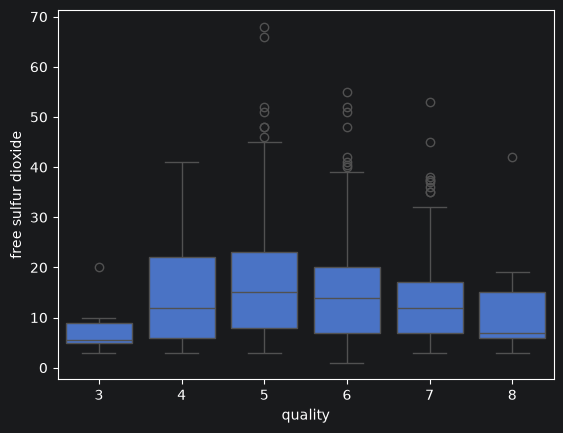

In [39]:
sns.boxplot(x='quality',y='free sulfur dioxide',data=df)
plt.show()

Free sulfur dioxide does not show a clear monotonic relationship with wine quality. Median values vary across quality groups, peaking around quality 5 before declining at higher quality levels. Several high-value potential outliers are present, especially for quality 5–7

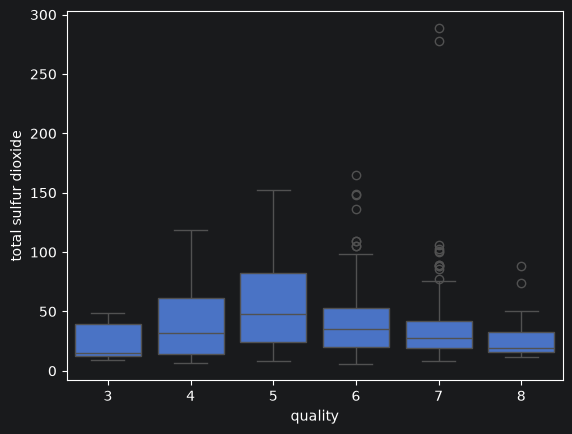

In [40]:
sns.boxplot(x='quality',y='total sulfur dioxide',data=df)
plt.show()

In [41]:
# Correlation Analysis with target
df.corr(numeric_only=True)['quality'].sort_values(ascending=False)


quality                 1.000000
alcohol                 0.485953
sulphates               0.257519
citric acid             0.241565
fixed acidity           0.115826
residual sugar          0.022718
pH                     -0.057592
free sulfur dioxide    -0.071083
chlorides              -0.122214
total sulfur dioxide   -0.182214
density                -0.185187
volatile acidity       -0.409340
Name: quality, dtype: float64

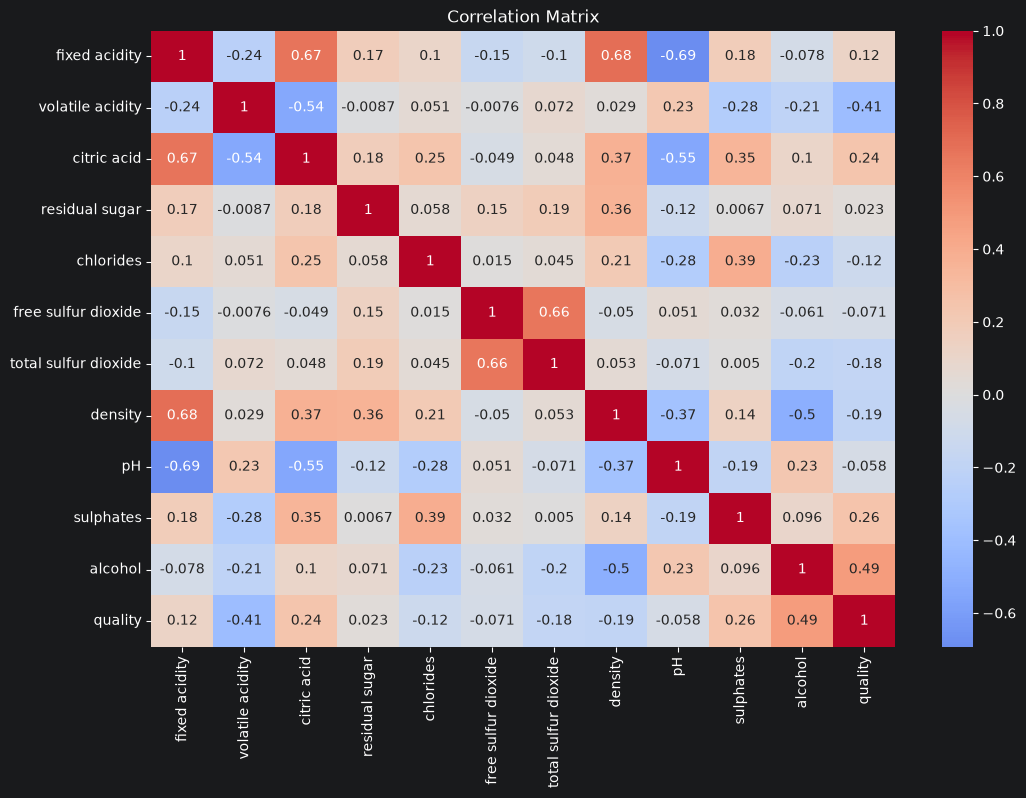

In [42]:
# Feature Correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,center=0,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [43]:
# fixed acidity x citric acid ->0.67
#fixed acidity x density ->0.68
#fixed acidity x ph ->-0.67
# free sulphur x total sulphur -> 0.66

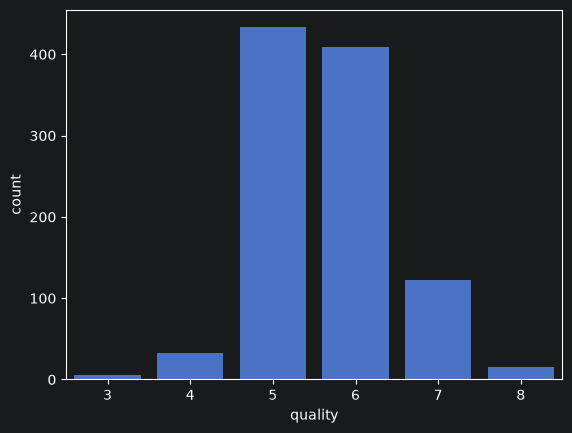

In [44]:
# Target Distribution
sns.countplot(x='quality',data=df)
plt.show()

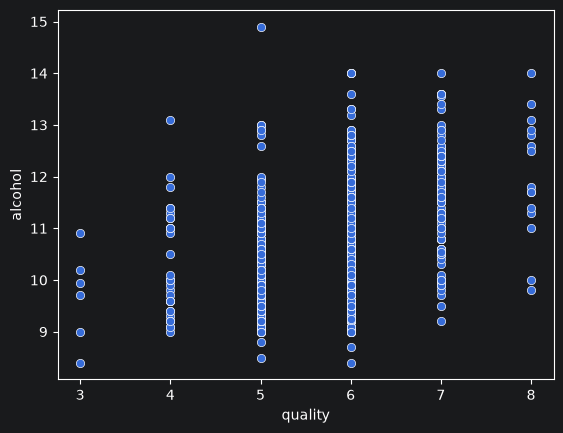

In [45]:
sns.scatterplot(data=df,x='quality',y='alcohol')
plt.show()

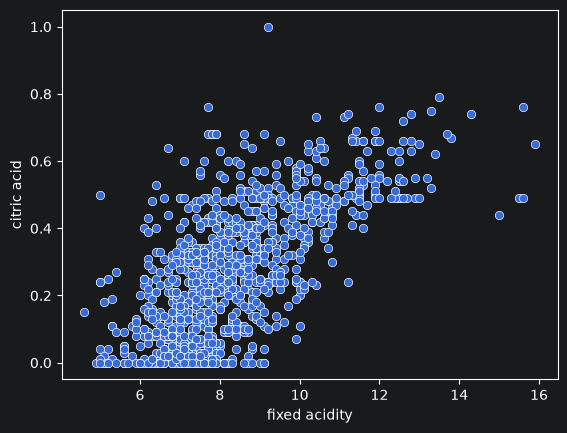

In [46]:
sns.scatterplot(data=df,x='fixed acidity',y='citric acid')
plt.show()

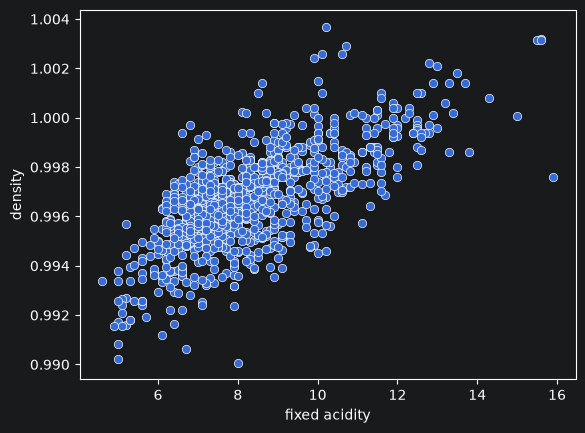

In [47]:
sns.scatterplot(data=df,x='fixed acidity',y='density')
plt.show()

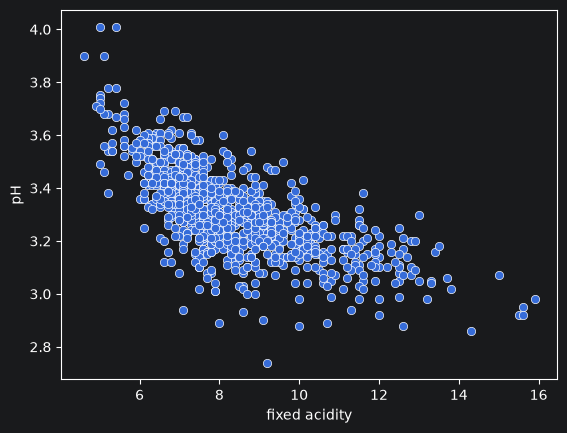

In [48]:
sns.scatterplot(data=df,x='fixed acidity',y='pH')
plt.show()

Feature Engineering

In [49]:
X=df.drop(columns='quality')
y=df['quality']

In [50]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


In [51]:
X.shape

(1018, 11)

In [52]:
y.shape

(1018,)

In [53]:
X.skew().sort_values(ascending=False)

chlorides               5.933225
residual sugar          4.350318
sulphates               2.424667
total sulfur dioxide    1.680327
free sulfur dioxide     1.172090
fixed acidity           1.037193
alcohol                 0.848859
volatile acidity        0.719668
citric acid             0.368824
pH                      0.257993
density                 0.091874
dtype: float64

In [54]:
X.describe().T[['min','max','mean','std']]

,min,max,mean,std
fixed acidity,4.60000,15.90000,8.288507,1.741324
volatile acidity,0.12000,1.58000,0.533541,0.183167
citric acid,0.00000,1.00000,0.268802,0.196229
residual sugar,0.90000,15.50000,2.524411,1.314850
chlorides,0.01200,0.61100,0.087187,0.048506
free sulfur dioxide,1.00000,68.00000,15.648821,10.176525
total sulfur dioxide,6.00000,289.00000,46.325639,33.123533
density,0.99007,1.00369,0.996700,0.001916
pH,2.74000,4.01000,3.311503,0.157775
sulphates,0.33000,2.00000,0.656817,0.167542


In [55]:
# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0,shuffle=True)

In [56]:
# Training our Baseline Model
model = LogisticRegression(
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Classification metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Accuracy: 0.6176470588235294

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.61      0.82      0.70        84
           6       0.64      0.59      0.61        95
           7       0.33      0.06      0.11        16
           8       0.00      0.00      0.00         1

    accuracy                           0.62       204
   macro avg       0.26      0.25      0.24       204
weighted avg       0.57      0.62      0.58       204


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  5  2  0  0]
 [ 0  0 69 15  0  0]
 [ 0  0 37 56  2  0]
 [ 0  0  1 14  1  0]
 [ 0  0  0  1  0  0]]


C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\P

In [57]:
# Log Transform and Scaling
log_cols=['chlorides','residual sugar','sulphates','total sulfur dioxide']
preprocessor=ColumnTransformer(
    transformers=[('log_scale',
                   Pipeline(
                       steps=[
                           ('log',FunctionTransformer(func=np.log1p)),
                           ('scaler',StandardScaler())
                       ]
                   ),log_cols)
        ,('scale_others',StandardScaler(),[col for col in X_train.columns if col not in log_cols])],
    remainder='passthrough'
)

model=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('lr',LogisticRegression(random_state=42)),
    ]
)

In [58]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

 #Classification metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.5980392156862745

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.62      0.79      0.69        84
           6       0.62      0.51      0.56        95
           7       0.40      0.50      0.44        16
           8       0.00      0.00      0.00         1

    accuracy                           0.60       204
   macro avg       0.27      0.30      0.28       204
weighted avg       0.58      0.60      0.58       204


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  3  4  0  0]
 [ 0  0 66 17  1  0]
 [ 0  0 37 48 10  0]
 [ 0  0  0  8  8  0]
 [ 0  0  0  0  1  0]]


C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [59]:
# Outlier Treatmean
def remove_outlier_1qr(X_train,y_train,outlier_cols):
    q1=X_train[outlier_cols].quantile(0.25)
    q3=X_train[outlier_cols].quantile(0.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    mask=~((X_train[outlier_cols]<lower) | (X_train[outlier_cols]>upper)).any(axis=1)

    return X_train[mask],y_train[mask]

In [60]:
outlier_cols=['chlorides','residual sugar','sulphates','total sulfur dioxide']
X_train_no_outlier,y_train_no_outliers=remove_outlier_1qr(X_train,y_train,outlier_cols)

In [61]:
model = LogisticRegression(
    random_state=42
)

model.fit(X_train_no_outlier, y_train_no_outliers)
y_pred = model.predict(X_test)


# Classification metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6274509803921569

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.61      0.79      0.68        84
           6       0.65      0.62      0.63        95
           7       0.75      0.19      0.30        16
           8       0.00      0.00      0.00         1

    accuracy                           0.63       204
   macro avg       0.33      0.27      0.27       204
weighted avg       0.61      0.63      0.60       204


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  6  1  0  0]
 [ 0  0 66 18  0  0]
 [ 0  0 35 59  1  0]
 [ 0  0  1 12  3  0]
 [ 0  0  0  1  0  0]]


C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\P

In [62]:
# Outlier Capping
def iqr_boundary(X,cols):
    q1=X[cols].quantile(0.25)
    q3=X[cols].quantile(0.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    return lower,upper

In [63]:
def iqr_capping(X,columns,lower,upper):
    X=X.copy()
    X[columns]=X[columns].clip(lower=lower,upper=upper,axis='columns')
    return X

In [64]:
lower,upper=iqr_boundary(X_train,outlier_cols)

In [65]:
lower

chlorides                0.040
residual sugar           0.850
sulphates                0.305
total sulfur dioxide   -41.000
dtype: float64

In [66]:
upper

chlorides                 0.120
residual sugar            3.650
sulphates                 0.985
total sulfur dioxide    125.000
dtype: float64

In [67]:
X_train_capped=iqr_capping(X_train,outlier_cols,lower,upper)
X_test_capped=iqr_capping(X_test,outlier_cols,lower,upper)

In [68]:
model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

model.fit(X_train_capped, y_train)
y_pred = model.predict(X_test_capped)


# Classification metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6078431372549019

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.62      0.77      0.69        84
           6       0.63      0.55      0.58        95
           7       0.44      0.44      0.44        16
           8       0.00      0.00      0.00         1

    accuracy                           0.61       204
   macro avg       0.28      0.29      0.28       204
weighted avg       0.58      0.61      0.59       204


Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 65 19  0  0]
 [ 0  0 35 52  8  0]
 [ 0  0  0  9  7  0]
 [ 0  0  0  0  1  0]]


C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thulu\PycharmProjects\Wine-Quality-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [69]:
# Comparing Different Models
models={
    'LogisticRegression':Pipeline([
        ('scaler',StandardScaler()),
        ('model',LogisticRegression(max_iter=1000,random_state=42))
    ]),
    'dt':DecisionTreeClassifier(random_state=42,max_depth=5),
    'rf':RandomForestClassifier(n_estimators=300,random_state=42),
    'gb':GradientBoostingClassifier(random_state=42),
    'bc':BaggingClassifier(random_state=42)
}

scoring={
    'accuracy':'accuracy',
    'precision':'precision_macro',
    'recall':'recall_macro',
    'f1':'f1_macro',

}

In [70]:
y_train[:5]

784    5
204    5
240    6
5      5
356    6
Name: quality, dtype: int64

In [71]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

results=[]

for name,model in models.items():
    scores=cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    results.append(
        {'Model':name,
         "Accuracy":scores['test_accuracy'].mean(),
         'Precision':scores['test_precision'].mean(),
         'Recall':scores['test_recall'].mean(),
         'f1':scores['test_f1'].mean()}
    )

cv_results=pd.DataFrame(results).sort_values('Accuracy')

In [72]:
cv_results

,Model,Accuracy,Precision,Recall,f1
4,bc,0.540567,0.261567,0.259656,0.257188
1,dt,0.542960,0.268226,0.259983,0.257786
3,gb,0.544232,0.331734,0.291175,0.297893
2,rf,0.582322,0.283011,0.277580,0.276224
0,LogisticRegression,0.590941,0.283291,0.284186,0.281442


Binarization

In [73]:
y_bin=df['quality'].apply(lambda x:1 if x>=6 else 0)

In [74]:
y_bin

0       0
1       0
2       0
3       1
4       0
       ..
1013    1
1014    1
1015    0
1016    1
1017    0
Name: quality, Length: 1018, dtype: int64

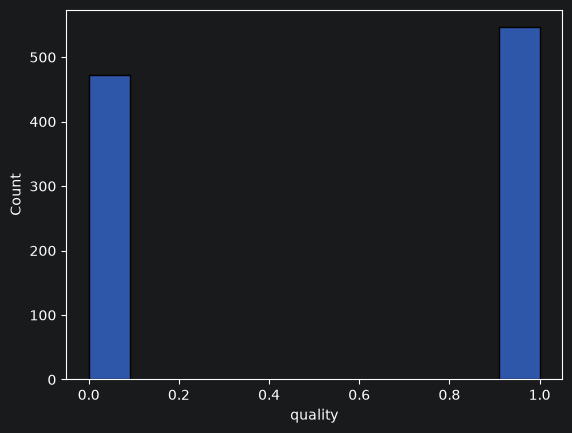

In [75]:
sns.histplot(y_bin)
plt.show()

In [76]:
X_train_bin,X_test_bin,y_train_bin,y_test_bin=train_test_split(X,y_bin,test_size=0.2,random_state=0,shuffle=True)

In [77]:

# Training RandomForest Classifier
rf=RandomForestClassifier(
    n_estimators=400,
    random_state=42
)
rf.fit(X_train_bin, y_train_bin)
y_pred1 = rf.predict(X_test_bin)


# Classification metrics
print("\nAccuracy:", accuracy_score(y_test_bin, y_pred1))

print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred1))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred1))


Accuracy: 0.7401960784313726

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73        92
           1       0.80      0.71      0.75       112

    accuracy                           0.74       204
   macro avg       0.74      0.74      0.74       204
weighted avg       0.75      0.74      0.74       204


Confusion Matrix:
[[72 20]
 [33 79]]


In [78]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

results=[]

for name,model in models.items():
    scores=cross_validate(
        model,
        X_train_bin,
        y_train_bin,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    results.append(
        {'Model':name,
         "Accuracy":scores['test_accuracy'].mean(),
         'Precision':scores['test_precision'].mean(),
         'Recall':scores['test_recall'].mean(),
         'f1':scores['test_f1'].mean()}
    )

cv_results1=pd.DataFrame(results).sort_values('Accuracy')

In [79]:
cv_results1

,Model,Accuracy,Precision,Recall,f1
1,dt,0.708831,0.712481,0.708552,0.706272
4,bc,0.724797,0.727466,0.726157,0.723981
3,gb,0.729698,0.729938,0.728452,0.728105
2,rf,0.743217,0.742496,0.742480,0.742188
0,LogisticRegression,0.749360,0.750559,0.748507,0.747962


In [86]:


# --------------------------------------------------
# Cross-validation strategy
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ==================================================
# 1. Logistic Regression
# ==================================================

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

lr_grid.fit(X_train_bin, y_train_bin)

print("LOGISTIC REGRESSION")
print("-" * 40)
print("Best Parameters:", lr_grid.best_params_)
print("Best CV F1:", lr_grid.best_score_)


# ==================================================
# 2. Random Forest
# ==================================================

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train_bin, y_train_bin)

print("\nRANDOM FOREST")
print("-" * 40)
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

LOGISTIC REGRESSION
----------------------------------------
Best Parameters: {'model__C': 100, 'model__solver': 'liblinear'}
Best CV F1: 0.75789774247374

RANDOM FOREST
----------------------------------------
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1: 0.7590438129524646


In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

for name, model in models.items():

    y_pred = model.predict(X_test_bin)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_test_bin, y_pred))
    print("Precision:", precision_score(y_test_bin, y_pred))
    print("Recall   :", recall_score(y_test_bin, y_pred))
    print("F1 Score :", f1_score(y_test_bin, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test_bin, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test_bin, y_pred))


Logistic Regression
Accuracy : 0.7009803921568627
Precision: 0.7741935483870968
Recall   : 0.6428571428571429
F1 Score : 0.7024390243902439

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.77      0.70        92
           1       0.77      0.64      0.70       112

    accuracy                           0.70       204
   macro avg       0.71      0.71      0.70       204
weighted avg       0.71      0.70      0.70       204

Confusion Matrix:
[[71 21]
 [40 72]]

Random Forest
Accuracy : 0.7352941176470589
Precision: 0.8020833333333334
Recall   : 0.6875
F1 Score : 0.7403846153846154

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73        92
           1       0.80      0.69      0.74       112

    accuracy                           0.74       204
   macro avg       0.74      0.74      0.74       204
weighted avg       0.75      0.74      0.74       20